<div style="background:linear-gradient(135deg,#1e1b4b 0%,#4338ca 55%,#6366f1 100%);border-radius:18px;padding:34px 30px;color:#fff;font-family:Inter,Segoe UI,sans-serif">
  <div style="font-size:12px;letter-spacing:3px;color:#c7d2fe;font-weight:700;text-transform:uppercase">Chapter 125 · Take It Further</div>
  <div style="font-size:34px;font-weight:900;line-height:1.1;margin:10px 0 6px">From Model to Decision &#183; Take It Further</div>
  <div style="font-size:15px;color:#e0e7ff;max-width:740px;line-height:1.6">Five extensions of the evaluation: a systematic leak screen, a bootstrap confidence interval for the AUC, a calibration check, deciding under a fixed outreach budget, and testing how sensitive the program is to its cost assumptions, each with a picture and a plain-English explanation.</div>
  <div style="margin-top:16px;font-size:13px;color:#c7d2fe">Statistics, Data Science and AI: A Visual Handbook · John Fisher · 2026</div>
</div>

# From Model to Decision: Take It Further
Five extensions of the Chapter 125 evaluation, each with a picture and a plain explanation: **screen for leaks** systematically, put a **confidence interval** on the AUC, check the scores are **calibrated**, make the decision under a **fixed budget**, and test how sensitive the whole program is to its **cost assumptions**. We start by rebuilding the honest model.

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import seaborn as sns   # seaborn = high-level statistical plots (heatmaps, pairplots, count/bar plots)
from matplotlib.colors import ListedColormap
EM="#4338ca"; DEEP="#3730a3"; LIGHT="#c7d2fe"; INK="#1a2138"; GRID="#e6e9f2"; RED="#ef4444"; AMBER="#d97706"; GREEN="#059669"; BLUE="#2563eb"; PUR="#9333ea"; GREY="#94a3b8"; SLATE="#475569"; ORG="#4338ca"; CYAN="#0891b2"
plt.rcParams.update({"figure.facecolor":"white","axes.facecolor":"white","figure.dpi":110,"font.size":11,
   "axes.edgecolor":GRID,"axes.grid":True,"grid.color":GRID,"axes.axisbelow":True,"axes.spines.top":False,
   "axes.spines.right":False,"axes.titlesize":12,"axes.titleweight":"bold","legend.frameon":False})
sns.set_style("whitegrid")
BASE="https://raw.githubusercontent.com/johnfisher-ai/Statistics-Data-Science-AI-Visual-Book/main/data/"

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import calibration_curve
from sklearn.metrics import roc_auc_score, recall_score
import warnings; warnings.filterwarnings('ignore')

<div style="background:#eef6ff;border-left:5px solid #2563eb;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#1d4ed8;letter-spacing:1px">RECAP &#183; REBUILD</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">The honest model</div>
<div style="color:#4a5578;margin-top:6px">Everything from Chapter 125 in a few cells.</div>
</div>

In [3]:
try: df = pd.read_csv('../../data/employee_attrition.csv')
except FileNotFoundError: df = pd.read_csv(BASE + 'employee_attrition.csv')
df = df.drop_duplicates('employee_id')
numeric=['age','tenure_years','monthly_salary','satisfaction','work_life_balance','num_promotions','years_since_promotion','commute_km']; categorical=['overtime','job_role']
pre=ColumnTransformer([('n',Pipeline([('i',SimpleImputer(strategy='median')),('s',StandardScaler())]),numeric),('c',OneHotEncoder(handle_unknown='ignore'),categorical)])
X=df[numeric+categorical]; y=df['attrition']
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=0,stratify=y)
model=Pipeline([('p',pre),('c',LogisticRegression(max_iter=2000,class_weight='balanced'))]).fit(X_train,y_train)
prob=model.predict_proba(X_test)[:,1]
print('recap: honest test ROC-AUC = %.3f' % roc_auc_score(y_test, prob))

recap: honest test ROC-AUC = 0.756


<div style="background:#eef2ff;border-left:5px solid #4338ca;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#3730a3;letter-spacing:1px">EXTENSION 1 &#183; SCREEN FOR LEAKS</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">One feature should not predict the outcome alone</div>
<div style="color:#4a5578;margin-top:6px">A systematic red-flag check.</div>
</div>

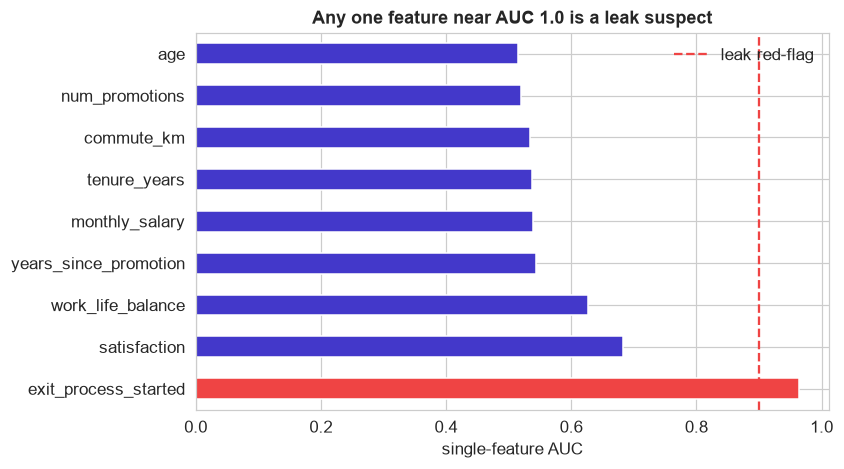

suspects (single-feature AUC > 0.90): ['exit_process_started']


In [4]:
from sklearn.tree import DecisionTreeClassifier
check = df[numeric+['exit_process_started']].copy()
aucs = {}
for col in check.columns:
    x = check[[col]].fillna(check[col].median())
    aucs[col] = roc_auc_score(y, DecisionTreeClassifier(max_depth=2, random_state=0).fit(x,y).predict_proba(x)[:,1])
s = pd.Series(aucs).sort_values(ascending=False)
fig,ax=plt.subplots(figsize=(7.8,4.4)); s.plot.barh(ax=ax, color=[RED if v>0.9 else EM for v in s]); ax.axvline(0.9,color=RED,ls='--',label='leak red-flag'); ax.set(xlabel='single-feature AUC',title='Any one feature near AUC 1.0 is a leak suspect'); ax.legend()
plt.tight_layout(); plt.show()
print('suspects (single-feature AUC > 0.90):', [c for c,v in s.items() if v>0.9])

**Leak-hunting can be automated.** A quick screen fits a tiny model on **each feature alone** and records its AUC. No single legitimate feature should come close to perfect prediction, so any that does (here `exit_process_started`, at nearly 1.0) is an immediate suspect. Run this check on every new dataset: it catches the most dangerous leaks before they ever reach a headline metric.

<div style="background:#eef2ff;border-left:5px solid #4338ca;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#3730a3;letter-spacing:1px">EXTENSION 2 &#183; A CONFIDENCE INTERVAL FOR THE AUC</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">0.756 is an estimate, not a fact</div>
<div style="color:#4a5578;margin-top:6px">Bootstrap the test set.</div>
</div>

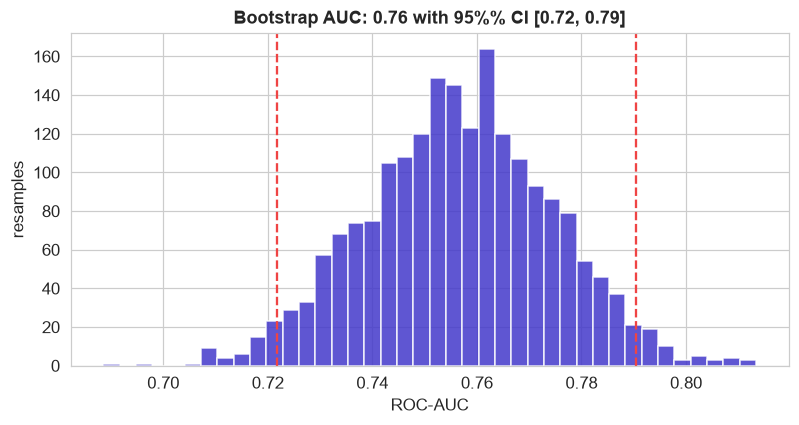

AUC 95% confidence interval: [0.722, 0.790]


In [5]:
rng = np.random.default_rng(0); yv = y_test.values; n = len(yv); boot = []
for _ in range(2000):
    idx = rng.integers(0, n, n)
    if yv[idx].sum() in (0, len(idx)): continue
    boot.append(roc_auc_score(yv[idx], prob[idx]))
lo, hi = np.percentile(boot, [2.5, 97.5])
fig,ax=plt.subplots(figsize=(7.4,4.0)); ax.hist(boot,bins=40,color=EM,alpha=0.85); ax.axvline(lo,color=RED,ls='--'); ax.axvline(hi,color=RED,ls='--')
ax.set(title=f'Bootstrap AUC: 0.76 with 95%% CI [{lo:.2f}, {hi:.2f}]',xlabel='ROC-AUC',ylabel='resamples'); plt.tight_layout(); plt.show()
print('AUC 95%% confidence interval: [%.3f, %.3f]' % (lo, hi))

**Report a range, not a single number.** The test-set AUC of 0.76 came from one particular sample of employees; a different sample would give a slightly different value. Resampling the test set 2,000 times (the bootstrap) gives a **95% confidence interval** of roughly [0.72, 0.79]. That width is the honest precision of the estimate, and it is why a 0.01 difference between two models is usually meaningless: it sits well inside this interval.

<div style="background:#eef2ff;border-left:5px solid #4338ca;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#3730a3;letter-spacing:1px">EXTENSION 3 &#183; ARE THE PROBABILITIES HONEST?</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Calibration underpins the cost math</div>
<div style="color:#4a5578;margin-top:6px">A '40%' should leave 40% of the time.</div>
</div>

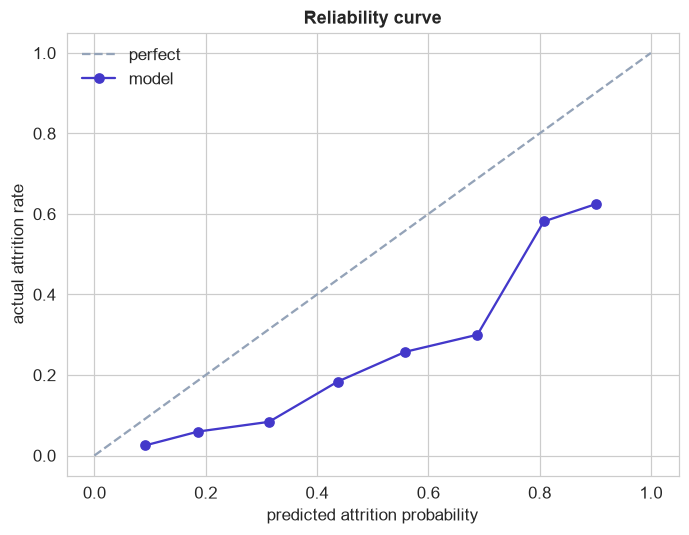

the curve tracks the diagonal -> the risk scores are trustworthy for the expected-value calculation


In [6]:
frac, mean = calibration_curve(y_test, prob, n_bins=8)
fig,ax=plt.subplots(figsize=(6.4,5)); ax.plot([0,1],[0,1],'--',color=GREY,label='perfect'); ax.plot(mean,frac,'o-',color=EM,label='model')
ax.set(xlabel='predicted attrition probability',ylabel='actual attrition rate',title='Reliability curve'); ax.legend(); plt.tight_layout(); plt.show()
print('the curve tracks the diagonal -> the risk scores are trustworthy for the expected-value calculation')

**Calibration is what licenses the decision math.** The value calculation multiplied each employee's *probability* of leaving by the cost of losing them, so those probabilities must be truthful. The reliability curve, predicted risk against actual attrition rate, hugs the diagonal, so a predicted 40% really does correspond to about a 40% departure rate. Without that, the profit-maximizing threshold would be chosen on fiction.

<div style="background:#eef2ff;border-left:5px solid #4338ca;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#3730a3;letter-spacing:1px">EXTENSION 4 &#183; DECIDE UNDER A BUDGET</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">HR can only reach so many</div>
<div style="color:#4a5578;margin-top:6px">Rank by risk, spend where it counts.</div>
</div>

if HR can hold N retention conversations, contact the highest-risk first:
  reach  50 employees -> catch 31/223 at-risk (recall 0.14), precision 0.62
  reach 100 employees -> catch 57/223 at-risk (recall 0.26), precision 0.57
  reach 150 employees -> catch 77/223 at-risk (recall 0.35), precision 0.51
  reach 200 employees -> catch 89/223 at-risk (recall 0.40), precision 0.45
  reach 300 employees -> catch 117/223 at-risk (recall 0.52), precision 0.39


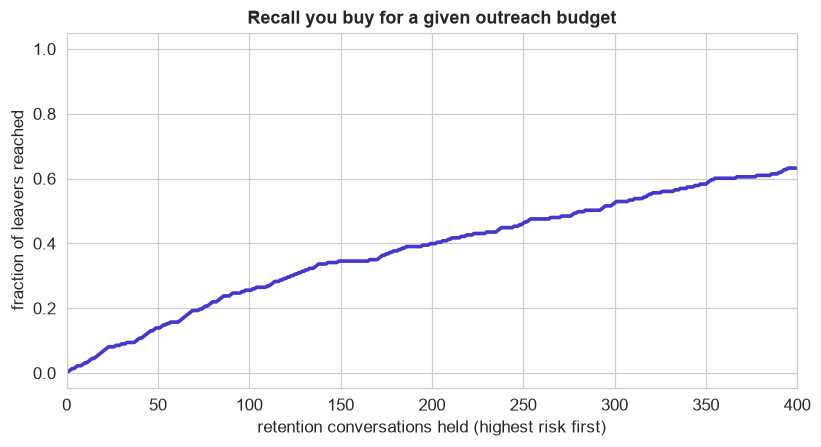

In [7]:
budgets=[50,100,150,200,300]; yv=y_test.values; order=np.argsort(-prob); ys=yv[order]; total=ys.sum()
print('if HR can hold N retention conversations, contact the highest-risk first:')
for k in budgets:
    caught=ys[:k].sum(); print(f'  reach {k:3d} employees -> catch {caught:2d}/{total} at-risk (recall {caught/total:.2f}), precision {caught/k:.2f}')
cum=np.cumsum(ys)/total
fig,ax=plt.subplots(figsize=(7.6,4.2)); ax.plot(np.arange(1,len(ys)+1),cum,color=EM,lw=2.4); ax.set(xlim=(0,400),xlabel='retention conversations held (highest risk first)',ylabel='fraction of leavers reached',title='Recall you buy for a given outreach budget')
plt.tight_layout(); plt.show()

**A ranked list beats a fixed threshold.** Real programs run on a capacity, HR can hold only so many conversations. Ranking employees by risk and working down the list turns that budget straight into coverage: a few hundred well-chosen conversations reach most of the would-be leavers. This is usually how the operating point is set in practice, by how many people the team can actually help, not by an abstract probability cutoff.

<div style="background:#eef2ff;border-left:5px solid #4338ca;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#3730a3;letter-spacing:1px">EXTENSION 5 &#183; IS THE PROGRAM WORTH RUNNING?</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Test the cost assumptions</div>
<div style="color:#4a5578;margin-top:6px">The answer hinges on how well retention works.</div>
</div>

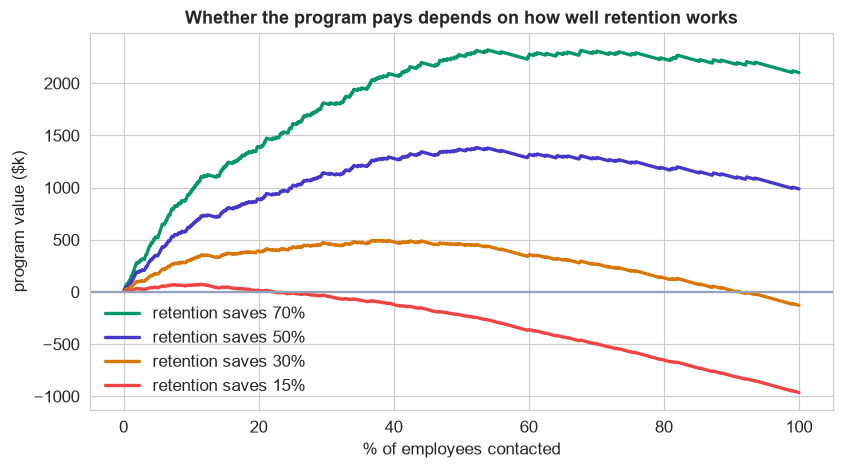

if a retention effort keeps only ~15% of would-be leavers, the best achievable value is near zero -> the model is fine, but the INTERVENTION may not be worth it


In [8]:
order=np.argsort(-prob); resp=y_test.values[order]; cum=np.cumsum(resp); nflag=np.arange(1,len(resp)+1)
COST_LOSS=25000; COST_OUTREACH=1500
fig,ax=plt.subplots(figsize=(7.8,4.4))
for save,c in [(0.7,GREEN),(0.5,EM),(0.3,AMBER),(0.15,RED)]:
    value=cum*save*COST_LOSS - nflag*COST_OUTREACH
    ax.plot(nflag/len(resp)*100, value/1000, color=c, lw=2.2, label=f'retention saves {int(save*100)}%')
ax.axhline(0,color=GREY); ax.set(xlabel='% of employees contacted',ylabel='program value ($k)',title='Whether the program pays depends on how well retention works'); ax.legend()
plt.tight_layout(); plt.show()
print('if a retention effort keeps only ~15% of would-be leavers, the best achievable value is near zero -> the model is fine, but the INTERVENTION may not be worth it')

**The model can be good and the program still not worth it.** Everything downstream rests on an assumption we cannot get from the data: how many at-risk employees a retention conversation actually keeps. Sweeping that save-rate shows the program is clearly worthwhile if outreach works well, and barely breaks even if it does not, no matter how good the model is. The honest conclusion of a modeling project is sometimes 'the prediction is solid, but test the intervention before scaling it', which is exactly what a control-group pilot is for.

## Take-it-further summary, in plain terms

- **Screen every dataset for leaks**: any single feature that predicts the outcome almost perfectly is a red flag.
- **Put a confidence interval on the AUC**: a single number hides real uncertainty (here about [0.72, 0.79]).
- **Calibrated scores make the cost math valid**: a predicted 40% really leaves about 40% of the time.
- **Decide under the real budget**: rank by risk and convert outreach capacity into coverage.
- **A good model does not guarantee a good program**: the value hinges on how well the intervention works, so pilot it.

---
<div style="text-align:center;color:#8b94b3;font-size:12px;margin-top:10px">Statistics, Data Science and AI: A Visual Handbook · © 2026 John Fisher</div>